In [624]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from fuzzywuzzy import process
from sklearn.metrics import silhouette_score

In [625]:
df = pd.read_csv("Bangladesh_Crime_Dataset_B.csv", index_col=0)

In [626]:
df.duplicated().sum()

290

# Exploratory Data Analysis

In [627]:
df.head()

,incident_month,incident_week,incident_weekday,weekend,part_of_the_day,incident_district,incident_division,precip,visibility,heatindex,...,average_household_size,density_per_kmsq,literacy_rate,religious_institution,playground,park,police_station,school,college,crime
0,7,29,wednesday,0,morning,dhaka,dhaka,6.1,10,32,...,8.42,30551,74.6,4289,99,17,60,242,64,murder
1,1,2,wednesday,0,night,dhaka,dhaka,0.0,10,22,...,8.42,30551,74.6,4289,99,17,60,242,64,murder
2,1,4,tuesday,0,night,dhaka,dhaka,0.0,10,25,...,8.42,30551,74.6,4289,99,17,60,242,64,murder
3,3,9,friday,1,night,dhaka,dhaka,0.0,10,30,...,8.42,30551,74.6,4289,99,17,60,242,64,murder
4,8,34,thursday,0,night,dhaka,dhaka,21.9,9,38,...,8.42,30551,74.6,4289,99,17,60,242,64,murder


In [628]:
df.describe()

,incident_month,incident_week,weekend,precip,visibility,heatindex,male_population,female_population,total_population,gender_ration,average_household_size,density_per_kmsq,literacy_rate,religious_institution,playground,park,police_station,school,college
count,6574.000000,6574.000000,6574.000000,5917.000000,6574.000000,6574.000000,6.574000e+03,6.574000e+03,6.574000e+03,6574.000000,6574.000000,6574.000000,6246.000000,6574.000000,6574.000000,6574.000000,6574.000000,6574.000000,6574.000000
mean,6.193185,25.193946,0.273806,6.136775,9.488287,31.597657,8.936342e+05,7.544586e+05,1.648104e+06,104.429723,4.965023,6362.512017,55.742683,1219.757073,42.504411,3.863706,11.762093,75.218893,15.479617
std,3.321934,14.517965,0.445944,11.778346,0.922742,5.502593,1.605205e+06,1.284180e+06,2.889245e+06,10.387173,1.422850,10368.342248,12.082504,1246.313725,44.857967,5.883186,19.604510,71.743767,19.721917
min,1.000000,1.000000,0.000000,0.000000,4.000000,15.000000,1.132000e+04,1.124700e+04,2.287100e+04,84.000000,3.580000,23.000000,26.700000,-99.000000,0.000000,0.000000,-1.000000,1.000000,0.000000
25%,3.000000,13.000000,0.000000,0.000000,9.000000,27.000000,1.319300e+05,1.339960e+05,2.652760e+05,98.000000,4.110000,924.000000,46.600000,509.500000,5.000000,0.000000,2.000000,30.000000,4.000000
50%,6.000000,25.000000,0.000000,0.800000,10.000000,33.000000,1.872290e+05,1.870170e+05,3.765500e+05,101.000000,4.440000,1239.000000,53.900000,797.000000,25.000000,1.000000,3.000000,45.000000,8.000000
75%,9.000000,37.000000,1.000000,7.400000,10.000000,36.000000,3.917070e+05,3.811572e+05,7.757330e+05,109.000000,5.100000,3977.000000,67.200000,1121.000000,78.000000,3.000000,6.000000,86.000000,15.000000
max,12.000000,53.000000,1.000000,204.600000,10.000000,43.000000,4.931802e+06,3.974237e+06,8.906039e+06,203.000000,8.420000,30551.000000,74.600000,4289.000000,253.000000,17.000000,74.000000,242.000000,64.000000


In [629]:
columns = df.select_dtypes(include=object).columns

for c in columns:
    print(df[c].value_counts())

incident_weekday
tuesday       912
wednesday     890
monday        889
thursday      837
saturday      822
             ... 
wednesdab       1
tyhursday       1
wednesdpay      1
shnday          1
satupday        1
Name: count, Length: 400, dtype: int64
part_of_the_day
night        3179
morning      1946
noon          517
evening       484
afternoon     331
Name: count, dtype: int64
incident_district
dhaka         1169
chattogram     491
mymensingh     269
jashore        261
dinajpur       209
              ... 
magura          17
sherpur         16
shariatpur      15
kurigram        10
narail          10
Name: count, Length: 64, dtype: int64
incident_division
dhaka         2046
chattogram    1061
rajshahi       782
rangpur        703
khulna         697
mymensingh     449
sylhet         424
barisal        408
gazipur          4
Name: count, dtype: int64
season
rainy     2716
winter    1831
hot       1699
Name: count, dtype: int64
crime
murder       1518
bodyfound    1517
rape         1

There are too many unique values that have a similarity with the real weekday (sunday - saturday). The solution is to change them based on the true weekday name.

In [630]:
df.select_dtypes(include=object).info()

<class 'pandas.core.frame.DataFrame'>
Index: 6574 entries, 0 to 6573
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   incident_weekday   6574 non-null   object
 1   part_of_the_day    6457 non-null   object
 2   incident_district  6574 non-null   object
 3   incident_division  6574 non-null   object
 4   season             6246 non-null   object
 5   crime              6574 non-null   object
dtypes: object(6)
memory usage: 359.5+ KB


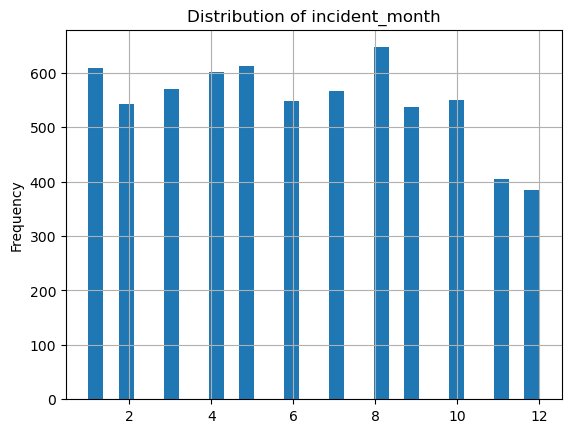

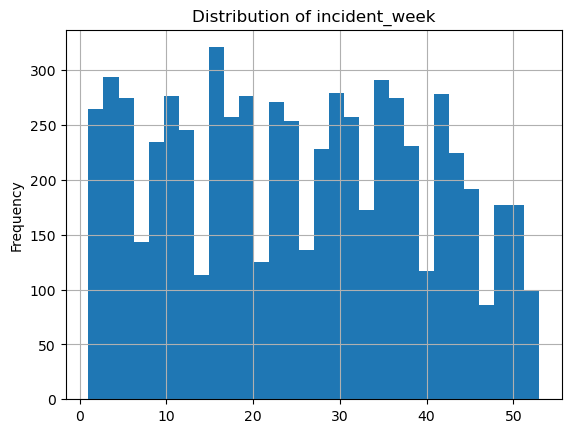

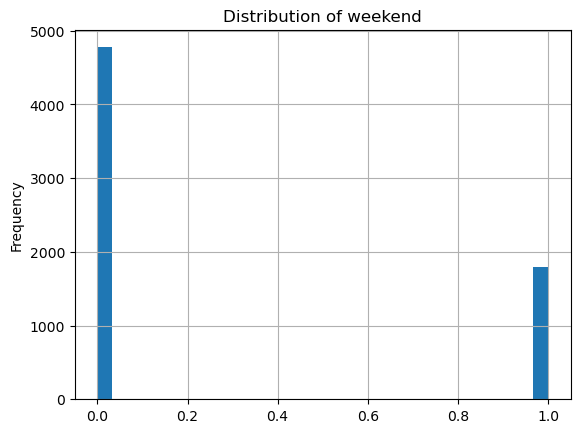

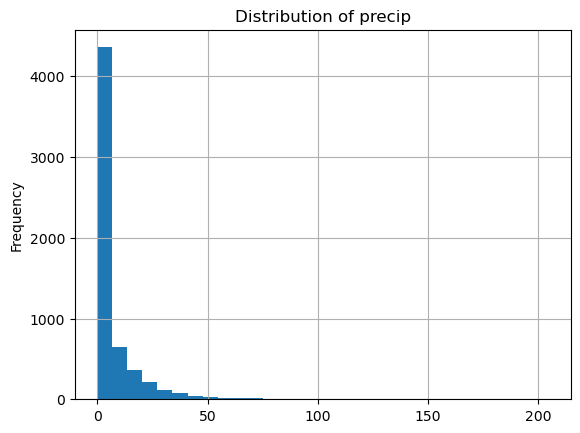

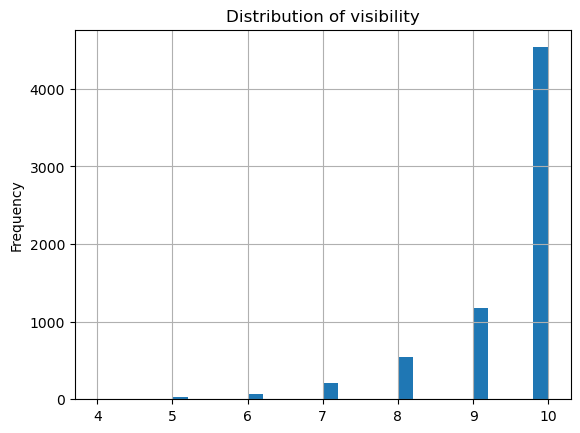

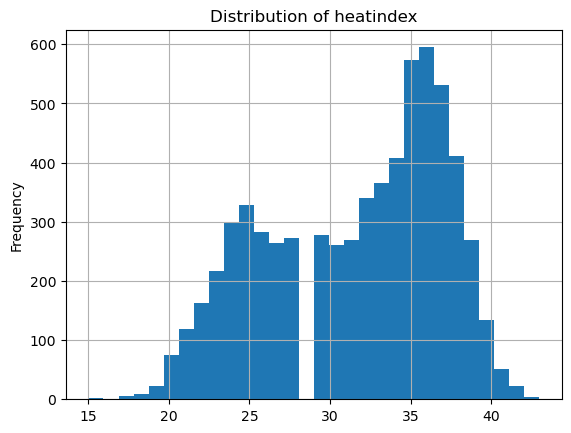

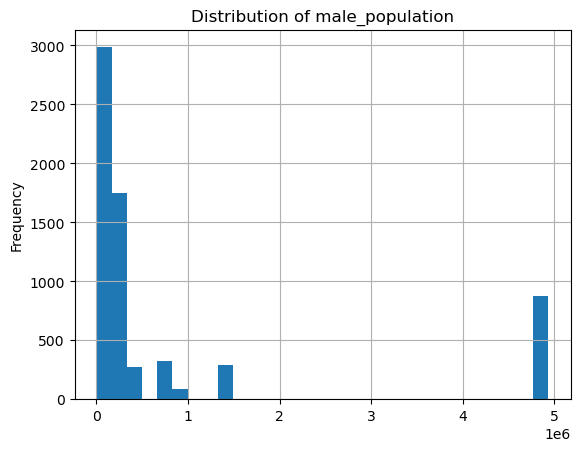

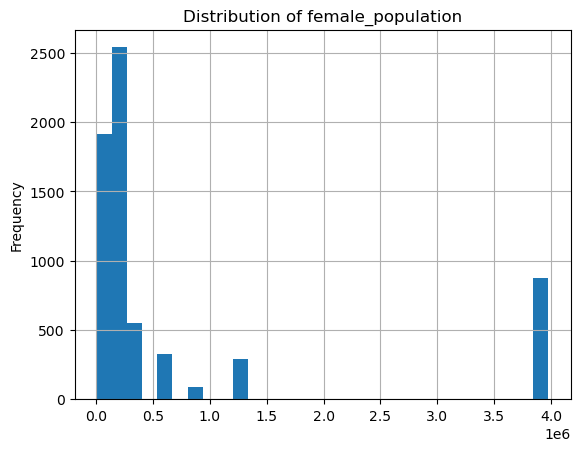

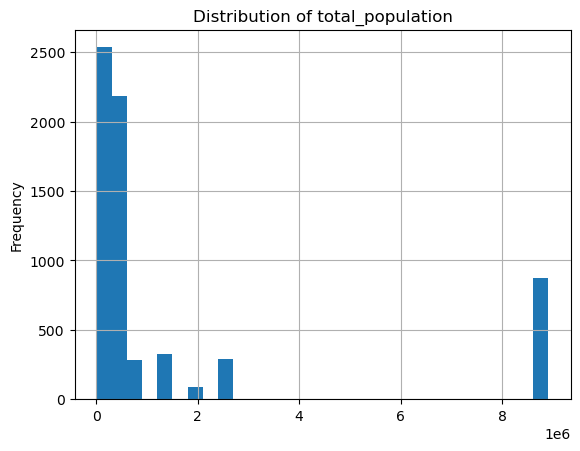

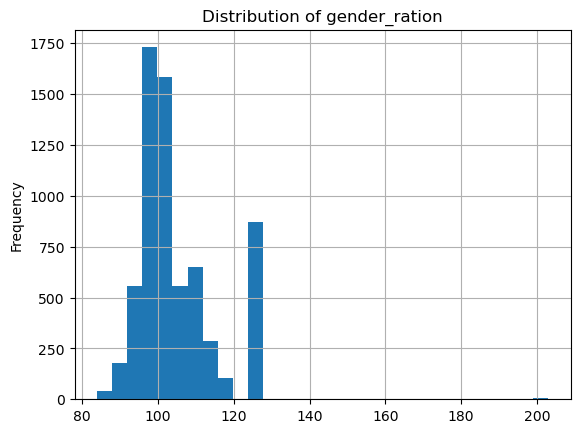

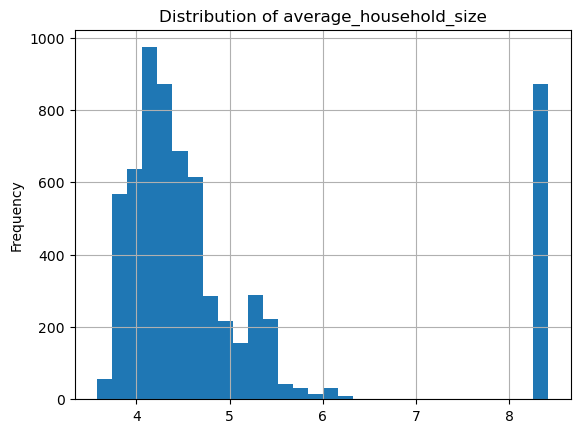

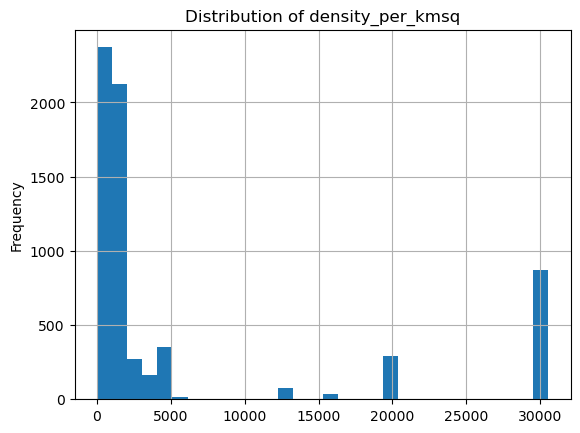

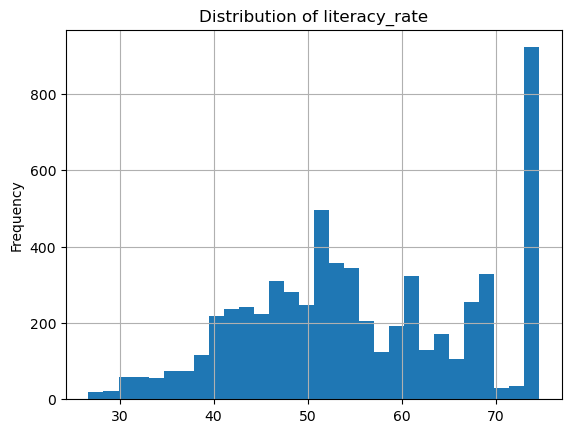

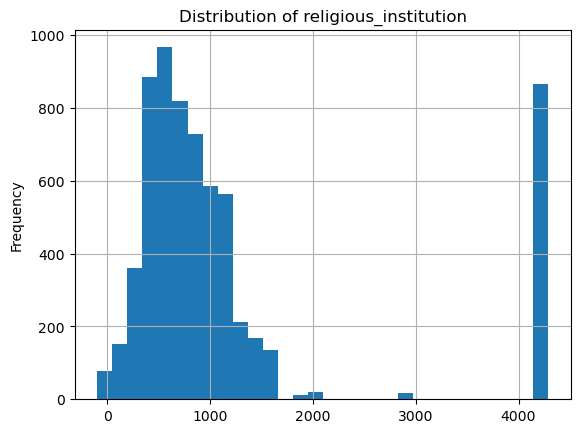

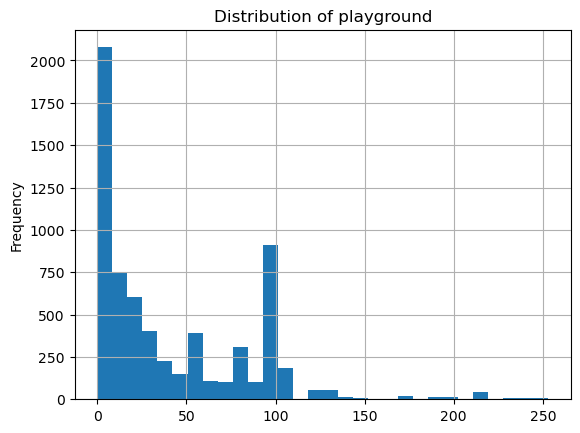

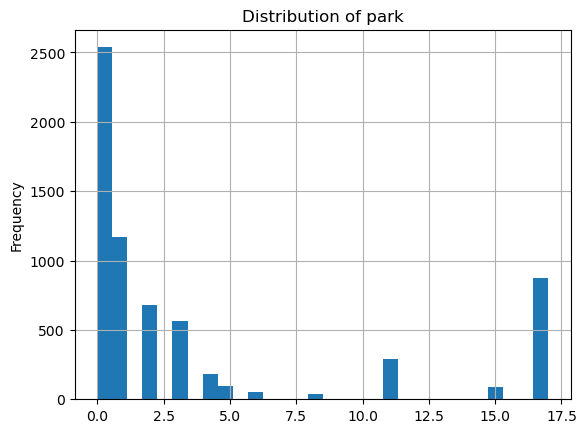

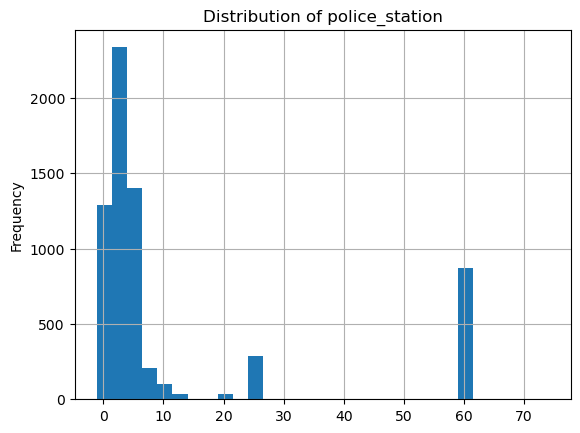

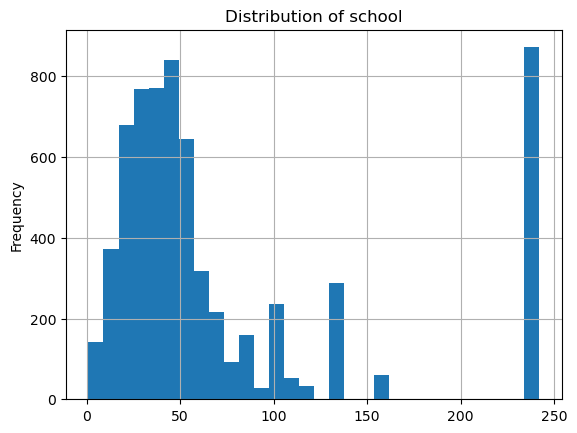

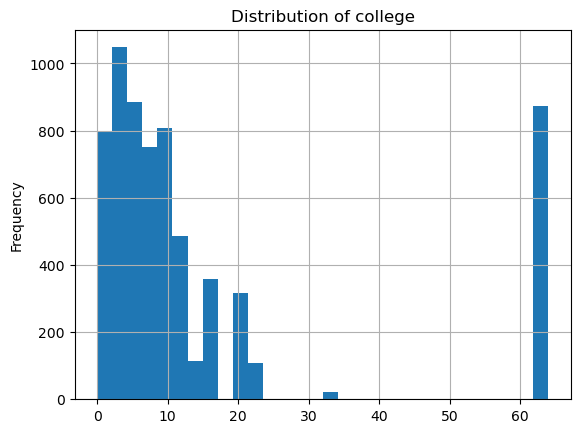

In [631]:
num_cols = df.select_dtypes(exclude=object).columns

for i in num_cols:
    df[i].dropna().hist(bins=30)
    plt.ylabel("Frequency")
    plt.title(f"Distribution of {i}")
    plt.show()

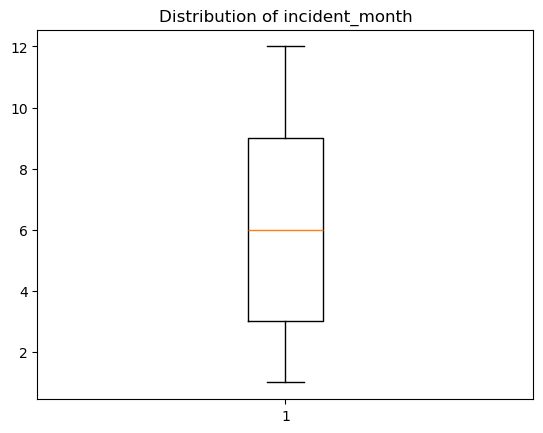

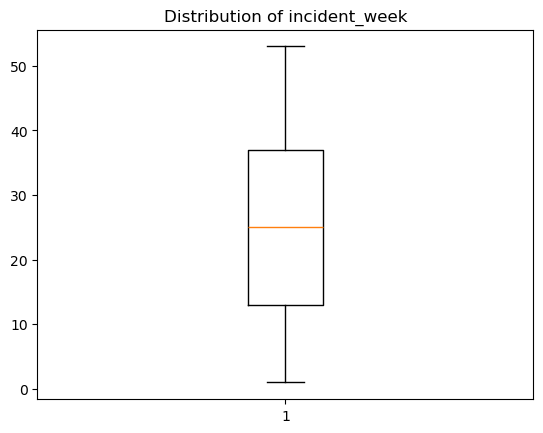

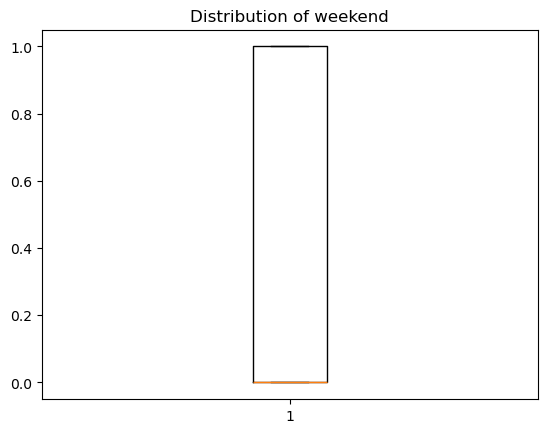

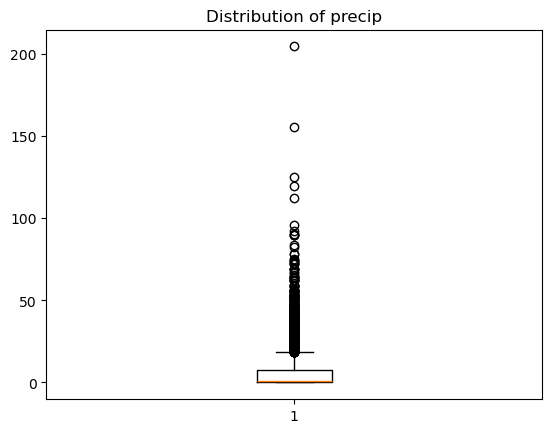

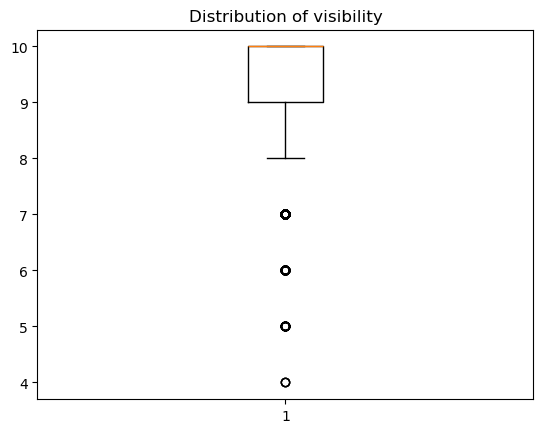

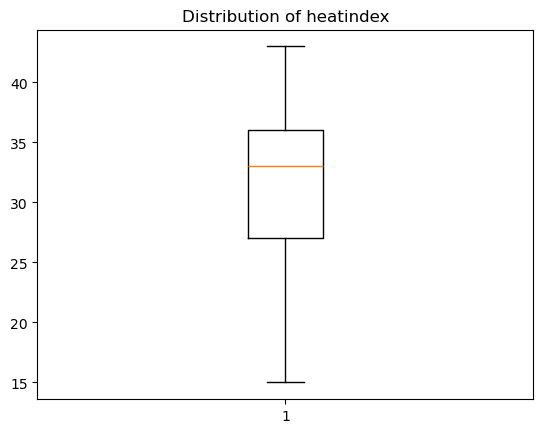

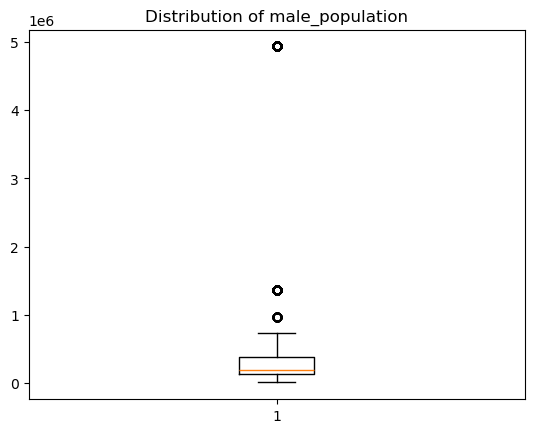

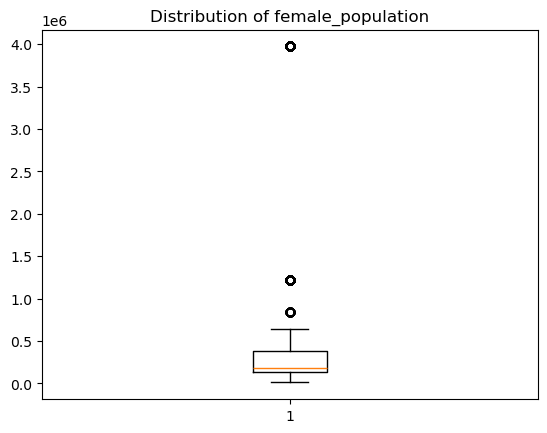

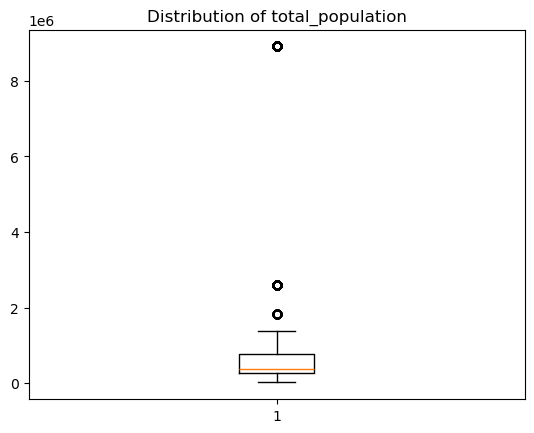

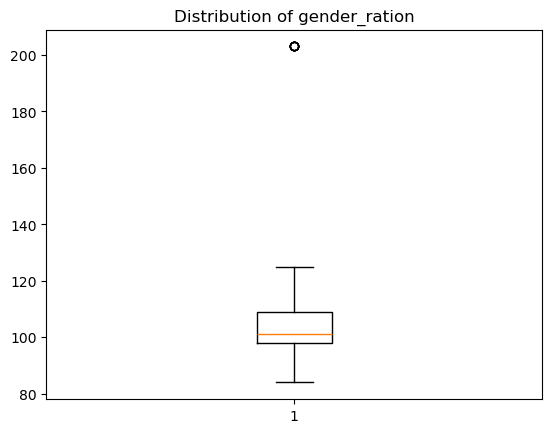

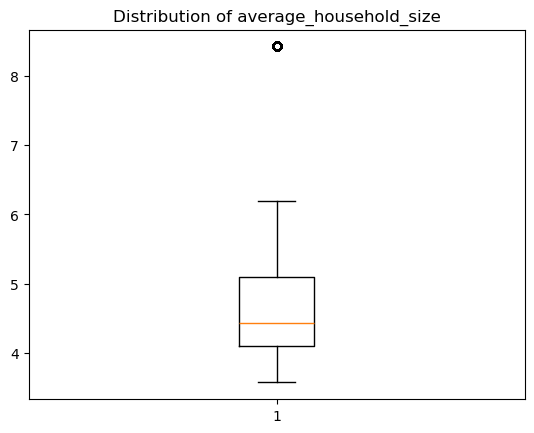

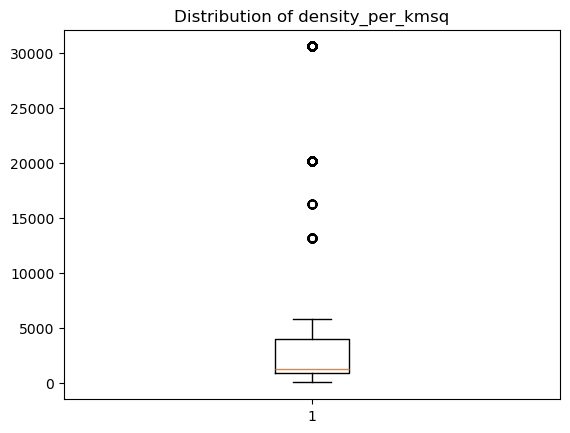

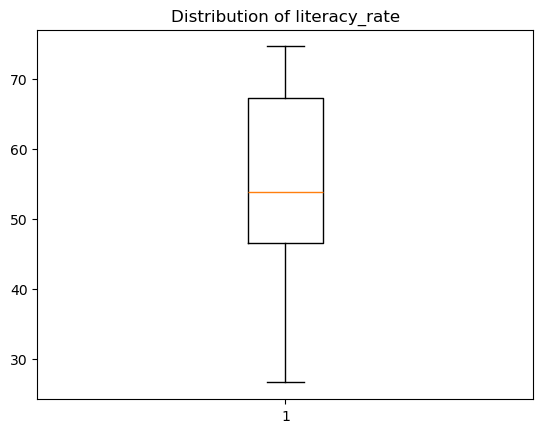

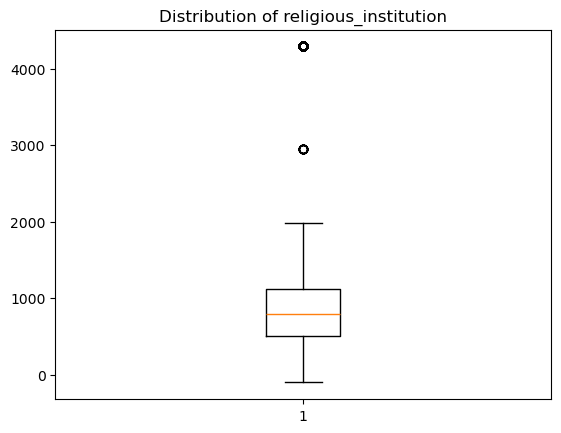

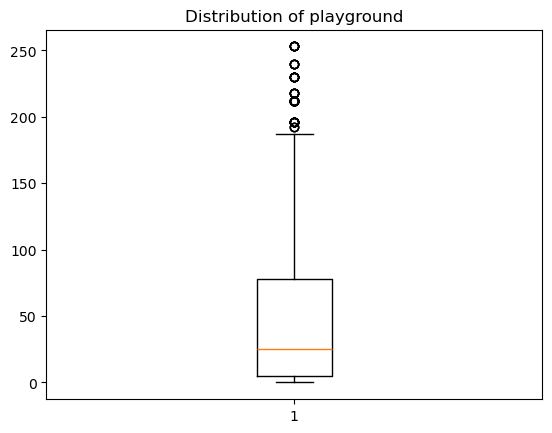

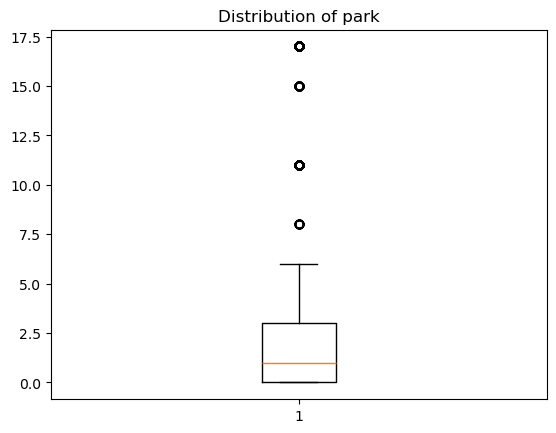

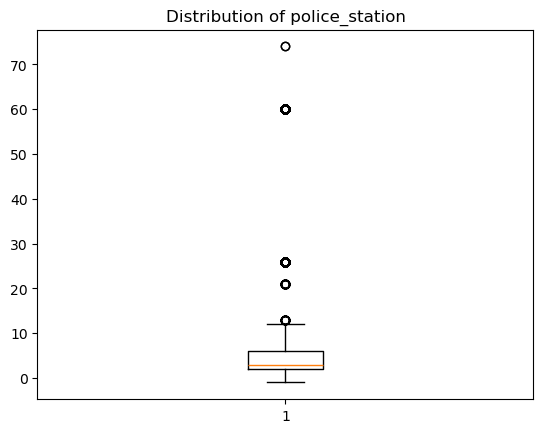

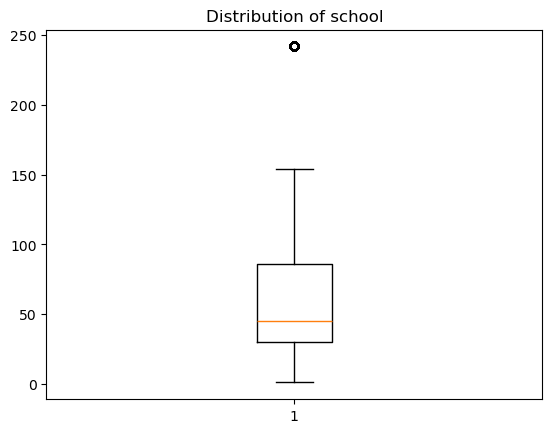

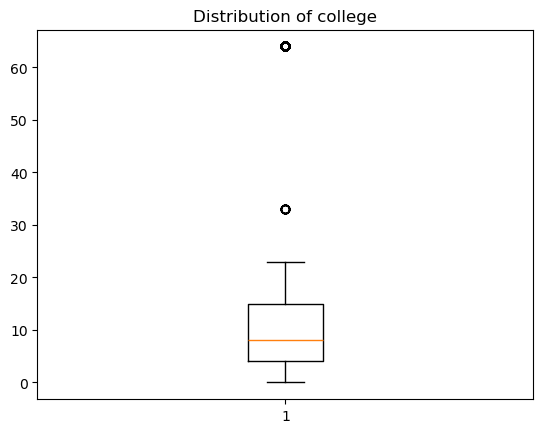

In [632]:
for i in num_cols:
    plt.boxplot(df[i].dropna())
    plt.title(f"Distribution of {i}")
    plt.show()

In [633]:
df.isna().sum()

incident_month              0
incident_week               0
incident_weekday            0
weekend                     0
part_of_the_day           117
incident_district           0
incident_division           0
precip                    657
visibility                  0
heatindex                   0
season                    328
male_population             0
female_population           0
total_population            0
gender_ration               0
average_household_size      0
density_per_kmsq            0
literacy_rate             328
religious_institution       0
playground                  0
park                        0
police_station              0
school                      0
college                     0
crime                       0
dtype: int64

In [634]:
df.duplicated().sum()

290

From the analysis above, there are some actions that have to be done:
1. There are 290 duplicated data. I have to remove them to remove the data noise.
2. There are many values in "part_of_the_day" column that have to be changed to the right days (Sunday, Monday, Tuesday, Wednesday, Thursday, Friday, and Saturday). The changes can be done by using fuzzywuzzy library to check the similarity from the right days.
3. There are null values in some columns. The solution is to fill the null values with modus for categorical columns and median for numerical columns in data training.
4. There are outliers in some columns and K-Means calculate the distance between value. Because of that, I'll use MinMaxScaler to encode all columns (numerical columns + encoded columns)

# Data Cleaning

In [635]:
df_clean = df.copy()

In [636]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6574 entries, 0 to 6573
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   incident_month          6574 non-null   int64  
 1   incident_week           6574 non-null   int64  
 2   incident_weekday        6574 non-null   object 
 3   weekend                 6574 non-null   int64  
 4   part_of_the_day         6457 non-null   object 
 5   incident_district       6574 non-null   object 
 6   incident_division       6574 non-null   object 
 7   precip                  5917 non-null   float64
 8   visibility              6574 non-null   int64  
 9   heatindex               6574 non-null   int64  
 10  season                  6246 non-null   object 
 11  male_population         6574 non-null   int64  
 12  female_population       6574 non-null   int64  
 13  total_population        6574 non-null   int64  
 14  gender_ration           6574 non-null   int64

In [637]:
df_clean.drop_duplicates(inplace=True)
df_clean.duplicated().sum()

0

Fix the typos that occured in columns incident weekday

In [638]:
days_reference = ["monday", "tuesday", "wednesday", "thursday", "friday", "saturday", "sunday"]

def fix_day_typo(typo, reference_list):
    best_match, score = process.extractOne(typo, reference_list)
    return best_match if score > 60 else typo

df_clean['incident_weekday'] = df_clean['incident_weekday'].apply(lambda x: fix_day_typo(str(x), days_reference))

In [639]:
df_clean['incident_weekday'].value_counts()

incident_weekday
tuesday      961
monday       932
wednesday    927
thursday     911
saturday     868
friday       853
sunday       832
Name: count, dtype: int64

In [640]:
cat_null_cols = ['part_of_the_day', 'season']

for i in cat_null_cols:
    df_clean[i] = df_clean[i].fillna(df_clean[i].mode()[0])

In [641]:
df_clean.select_dtypes(exclude=object).info()

<class 'pandas.core.frame.DataFrame'>
Index: 6284 entries, 0 to 6573
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   incident_month          6284 non-null   int64  
 1   incident_week           6284 non-null   int64  
 2   weekend                 6284 non-null   int64  
 3   precip                  5628 non-null   float64
 4   visibility              6284 non-null   int64  
 5   heatindex               6284 non-null   int64  
 6   male_population         6284 non-null   int64  
 7   female_population       6284 non-null   int64  
 8   total_population        6284 non-null   int64  
 9   gender_ration           6284 non-null   int64  
 10  average_household_size  6284 non-null   float64
 11  density_per_kmsq        6284 non-null   int64  
 12  literacy_rate           5956 non-null   float64
 13  religious_institution   6284 non-null   int64  
 14  playground              6284 non-null   int64

In [642]:
num_null_cols = ['precip', 'literacy_rate']

for i in num_null_cols:
    df_clean[i] = df_clean[i].fillna(df_clean[i].median())

# Feature Engineering

In [643]:
df_clean.select_dtypes(include=object).info()

<class 'pandas.core.frame.DataFrame'>
Index: 6284 entries, 0 to 6573
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   incident_weekday   6284 non-null   object
 1   part_of_the_day    6284 non-null   object
 2   incident_district  6284 non-null   object
 3   incident_division  6284 non-null   object
 4   season             6284 non-null   object
 5   crime              6284 non-null   object
dtypes: object(6)
memory usage: 343.7+ KB


The categorical columns have to be changed with Feature Engineering (Changing them with encoding). The encodings that will be applied are:
1. incident_weekday = OneHotEncoding. Reason: The number of unique value is much less 
and there are no any orders of value (hierarchy) so it's safe to do
2. part_of_the_day = OrdinalEncoding. Reason: There are orders of a day (Sunday, Monday, Tuesday, Wednesday, Thursday, Friday, and Saturday)
3. incident_district = Frequency Encoding. Reason: Using One Hot Encoding would make the machine learning heavier to work because there are many values that appear frequently. Because of that, frequency encoding would be the best for this column based on how many times per value appears.
4. incident_division = OneHotEncoding. Reason: The number of unique value is much less and there are no any orders of value (hierarchy) so it's safe to do
5. season = OneHotEncoding. Reason: The number of unique value is much less and there are no any orders of value (hierarchy) so it's safe to do
6. crime = OneHotEncoding. Reason: The number of unique value is much less and there are no any orders of value (hierarchy) so it's safe to do

After all encoding, I'll use MinMaxScaler to scale the entire feature set to ensure that every variable contributes equally to the distance calculations in the K-Means model.

One Hot Encoding

In [644]:
df_clean.isna().sum()

incident_month            0
incident_week             0
incident_weekday          0
weekend                   0
part_of_the_day           0
incident_district         0
incident_division         0
precip                    0
visibility                0
heatindex                 0
season                    0
male_population           0
female_population         0
total_population          0
gender_ration             0
average_household_size    0
density_per_kmsq          0
literacy_rate             0
religious_institution     0
playground                0
park                      0
police_station            0
school                    0
college                   0
crime                     0
dtype: int64

In [645]:
ohe = OneHotEncoder(sparse_output=False)
ohe_col = ['incident_weekday', 'season', 'incident_division', 'crime']
df_clean_2 = df_clean.reset_index(drop=True)

for i in ohe_col:
    encoded_data = ohe.fit_transform(df_clean[[i]])
    df_ohe = pd.DataFrame(encoded_data, columns=ohe.get_feature_names_out([i]), index=df_clean_2.index)
    df_clean_2 = pd.concat([df_clean_2, df_ohe], axis=1)
    df_clean_2 = df_clean_2.drop(i, axis=1)

In [646]:
df_clean_2.isna().sum()

incident_month                  0
incident_week                   0
weekend                         0
part_of_the_day                 0
incident_district               0
precip                          0
visibility                      0
heatindex                       0
male_population                 0
female_population               0
total_population                0
gender_ration                   0
average_household_size          0
density_per_kmsq                0
literacy_rate                   0
religious_institution           0
playground                      0
park                            0
police_station                  0
school                          0
college                         0
incident_weekday_friday         0
incident_weekday_monday         0
incident_weekday_saturday       0
incident_weekday_sunday         0
incident_weekday_thursday       0
incident_weekday_tuesday        0
incident_weekday_wednesday      0
season_hot                      0
season_rainy  

Frequency Encoding

In [647]:
dist_freq = df_clean_2['incident_district'].value_counts().to_dict()
df_clean_2['incident_district'] = df_clean_2['incident_district'].map(dist_freq)

Ordinal Encoding

In [648]:
day = {'morning': 0, 'noon': 1, 'afternoon': 2, 'evening': 3, 'night': 4}
df_clean_2['part_of_the_day'] = df_clean_2['part_of_the_day'].map(day)

MinMaxScaler

In [649]:
scaler = MinMaxScaler()
df_final = scaler.fit_transform(df_clean_2)

In [650]:
df_clean_2 = pd.DataFrame(df_final, columns = df_clean_2.columns)

In [651]:
df_clean_2.head()

,incident_month,incident_week,weekend,part_of_the_day,incident_district,precip,visibility,heatindex,male_population,female_population,...,incident_division_mymensingh,incident_division_rajshahi,incident_division_rangpur,incident_division_sylhet,crime_assault,crime_bodyfound,crime_kidnap,crime_murder,crime_rape,crime_robbery
0,0.545455,0.538462,0.0,0.0,1.0,0.029814,1.000000,0.607143,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,0.000000,0.019231,0.0,1.0,1.0,0.000000,1.000000,0.250000,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,0.000000,0.057692,0.0,1.0,1.0,0.000000,1.000000,0.357143,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,0.181818,0.153846,1.0,1.0,1.0,0.000000,1.000000,0.535714,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,0.636364,0.634615,0.0,1.0,1.0,0.107038,0.833333,0.821429,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


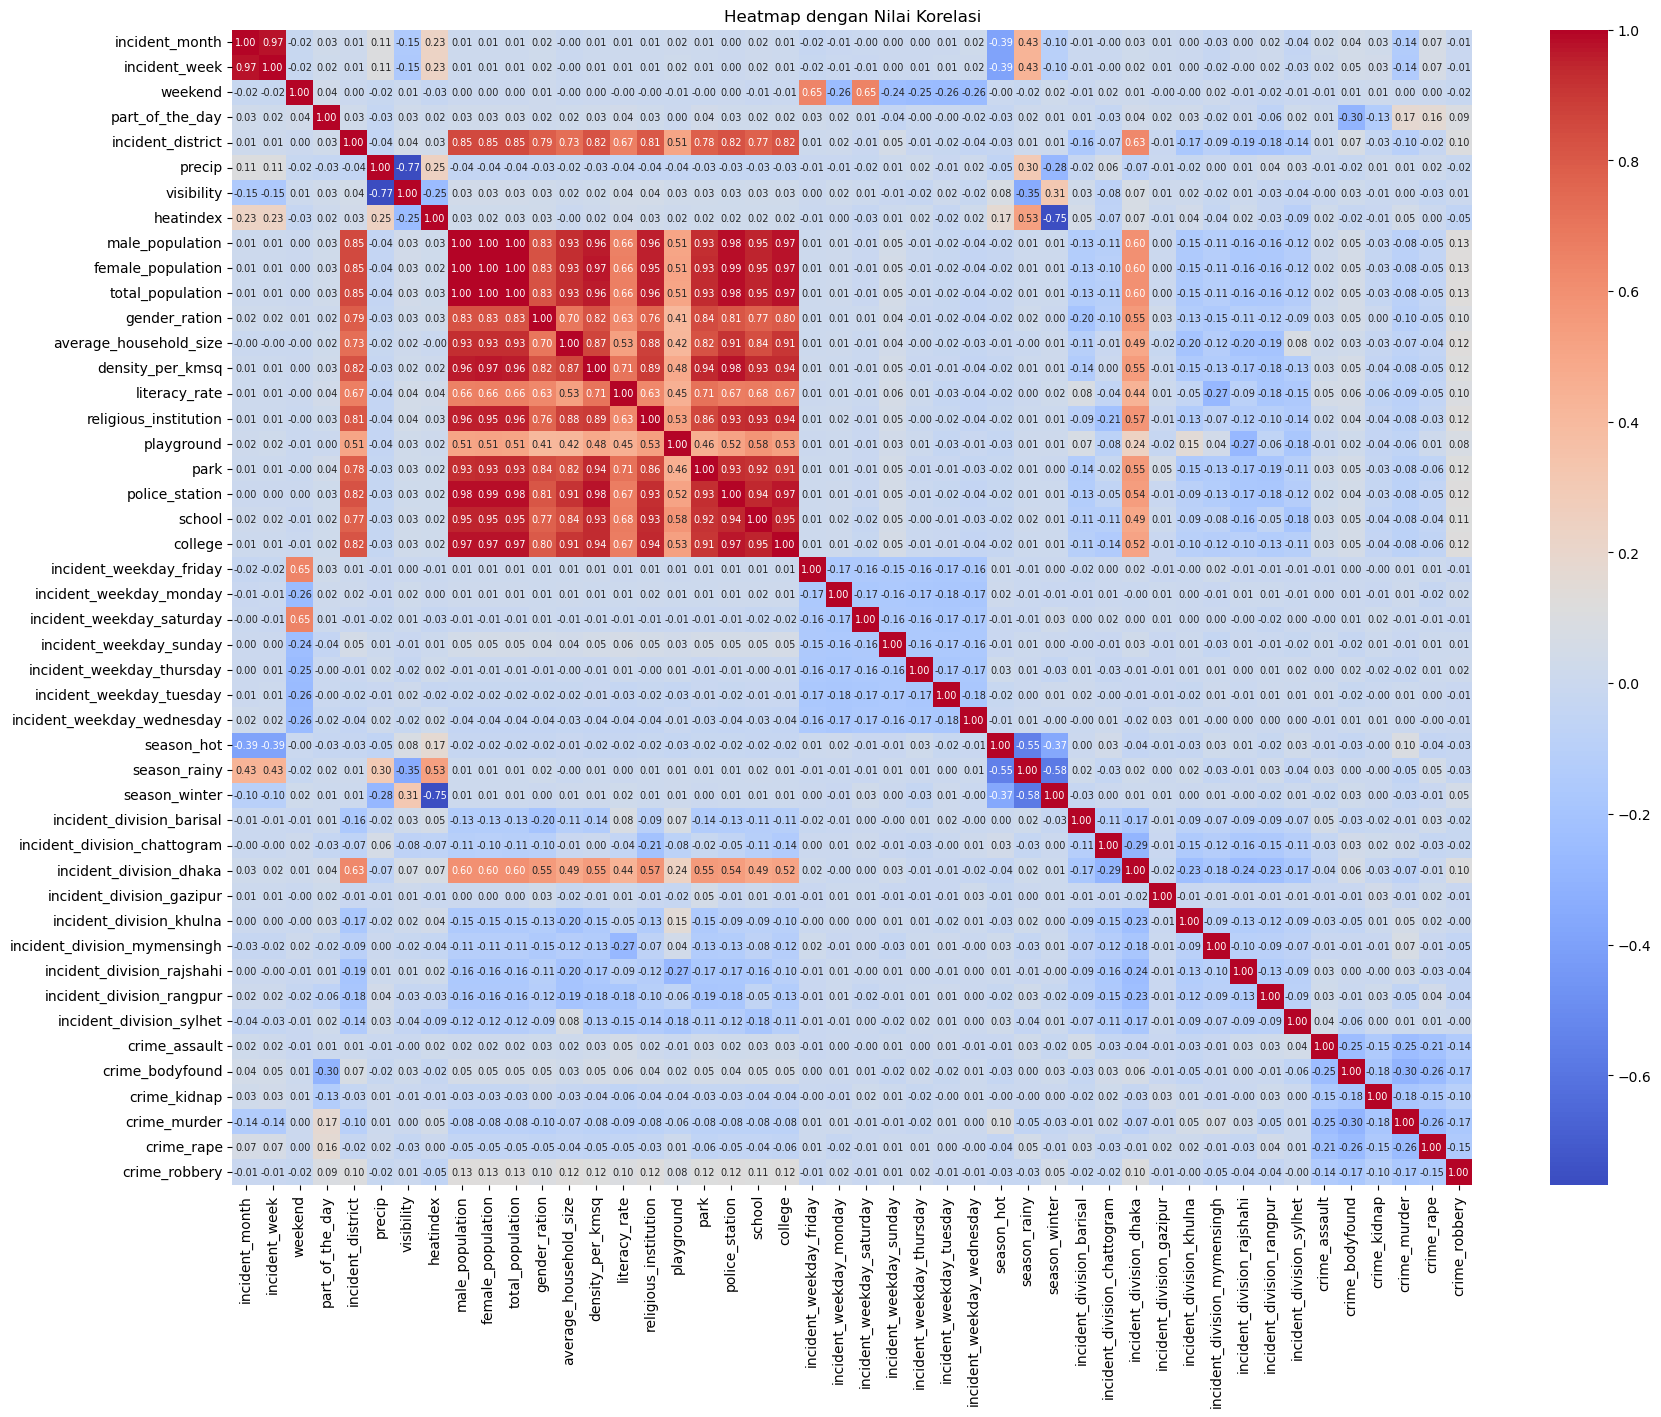

In [652]:
plt.figure(figsize=(20, 15)) # Perbesar ukuran gambar agar angka terbaca
sns.heatmap(df_clean_2.corr(), 
            annot=True,      # Menampilkan angka korelasi
            fmt=".2f",       # Membatasi 2 angka di belakang koma
            annot_kws={"size": 7}, # Mengecilkan ukuran font angka
            cmap='coolwarm')
plt.title('Heatmap dengan Nilai Korelasi')
plt.show()

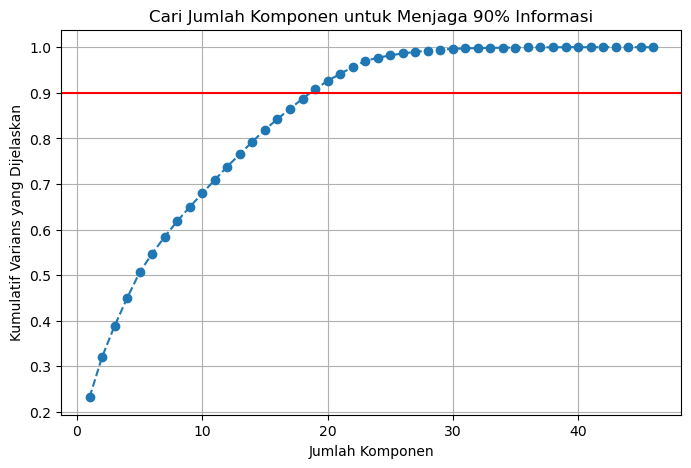

In [653]:
pca = PCA()
pca_data = pca.fit_transform(df_clean_2)
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--')
plt.axhline(y=0.90, color='r', linestyle='-')
plt.xlabel('Jumlah Komponen')
plt.ylabel('Kumulatif Varians yang Dijelaskan')
plt.title('Cari Jumlah Komponen untuk Menjaga 90% Informasi')
plt.grid()
plt.show()

# Modelling

In [654]:
pca = PCA(n_components=19)
X_pca = pca.fit_transform(df_clean_2)
sil_scores = []
inertias = []
K_range = range(2, 11) # Silhouette score minimal butuh 2 cluster

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_pca)
    score = silhouette_score(X_pca, labels)
    sil_scores.append(score)
    inertia = kmeans.inertia_
    inertias.append(inertia)
    print(f"k={k}, Silhouette Score: {score:.4f}")
    print(f"k={k}, Inertia Score: {inertia:.4f}")
    print("\n")

k=2, Silhouette Score: 0.3386
k=2, Inertia Score: 21630.2582


k=3, Silhouette Score: 0.1540
k=3, Inertia Score: 19339.2693


k=4, Silhouette Score: 0.1792
k=4, Inertia Score: 17763.5707


k=5, Silhouette Score: 0.1555
k=5, Inertia Score: 16920.1647


k=6, Silhouette Score: 0.1659
k=6, Inertia Score: 16349.8131


k=7, Silhouette Score: 0.1440
k=7, Inertia Score: 16047.5353


k=8, Silhouette Score: 0.1501
k=8, Inertia Score: 15432.4908


k=9, Silhouette Score: 0.1137
k=9, Inertia Score: 15200.6859


k=10, Silhouette Score: 0.1311
k=10, Inertia Score: 14772.9758




The silhouette score in k=2 shows that the cluster has separated with score 0.3386. This indicates that the cluster structure has clearly formed. Data points in Cluster 0 tend to be far from those in Cluster 1.

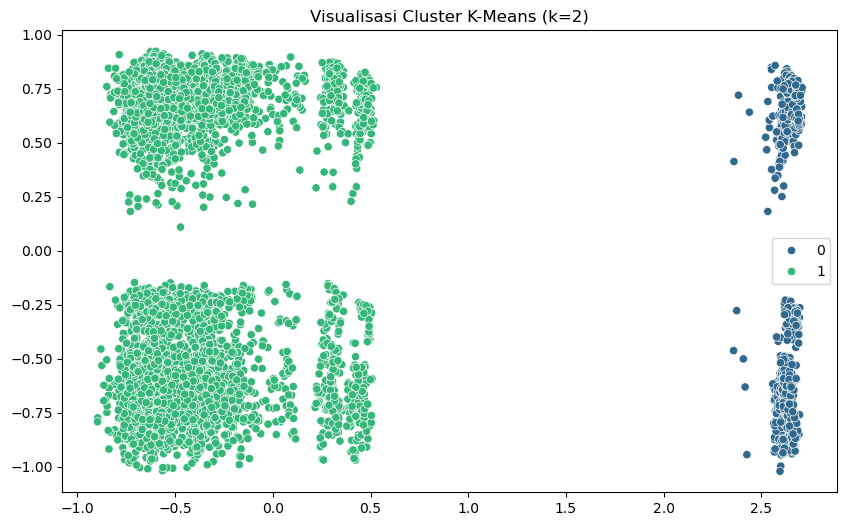

In [655]:
kmeans_final = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters = kmeans_final.fit_predict(X_pca) 
df_clean['cluster'] = clusters

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=clusters, palette='viridis')
plt.title('Visualisasi Cluster K-Means (k=2)')
plt.show()

In [ ]:
profile = df_clean.groupby('cluster').agg({
    'total_population': 'mean',
    'literacy_rate': 'mean',
    'crime': lambda x: x.mode()[0],
    'incident_division': lambda x: x.mode()[0]
})

print(profile)

         total_population  literacy_rate      crime incident_division
cluster                                                              
0            8.906039e+06      73.653430  bodyfound             dhaka
1            5.418802e+05      52.971447     murder             dhaka


In [659]:
num_prof = df_clean.groupby('cluster').agg({
    'total_population': 'mean',
    'literacy_rate': 'mean',
    'police_station': 'mean',
    'college': 'mean',
    'average_household_size': 'mean'
}).round(2)

cat_prof = df_clean.groupby('cluster').agg({
    'crime': lambda x: x.mode()[0],
    'incident_district': lambda x: x.mode()[0],
})

full_prof = num_prof.join(cat_prof)
print(full_prof)

         total_population  literacy_rate  police_station  college  \
cluster                                                             
0              8906039.00          73.65           59.93    64.00   
1               541880.23          52.97            4.42     8.08   

         average_household_size      crime incident_district  
cluster                                                       
0                          8.42  bodyfound             dhaka  
1                          4.43     murder        chattogram  
